# Books Web Scraping and Analysis

Beginner project using Books to Scrape.

## Import Libraries

In [1]:
!pip install requests beautifulsoup4 pandas matplotlib

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
from urllib.parse import urljoin

## Scrape Books from All Pages

In [3]:
books = []

for page in range(1, 51):
    url = f"https://books.toscrape.com/catalogue/page-{page}.html"
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")

    book_items = soup.find_all("article", class_="product_pod")

    for book in book_items:
        title = book.h3.a["title"]
        price = book.find("p", class_="price_color").text
        rating = book.find("p", class_="star-rating")["class"][1]
        availability = book.find("p", class_="instock availability").text.strip()
        product_url = urljoin(url, book.h3.a["href"])

        books.append({
            "Title": title,
            "Price": price,
            "Rating": rating,
            "Availability": availability,
            "Product_URL": product_url
        })

print("Total books scraped:", len(books))

Total books scraped: 1000


## Create DataFrame

In [17]:
df = pd.DataFrame(books)
df.head()

,Title,Price,Rating,Availability,Product_URL
0,A Light in the Attic,Â£51.77,Three,In stock,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,Â£53.74,One,In stock,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,Â£50.10,One,In stock,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,Â£47.82,Four,In stock,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock,https://books.toscrape.com/catalogue/sapiens-a...


In [18]:
df.shape

(1000, 5)

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Title         1000 non-null   str  
 1   Price         1000 non-null   str  
 2   Rating        1000 non-null   str  
 3   Availability  1000 non-null   str  
 4   Product_URL   1000 non-null   str  
dtypes: str(5)
memory usage: 39.2 KB


## Check Missing Values and Duplicates

In [20]:
df.isnull().sum()

Title           0
Price           0
Rating          0
Availability    0
Product_URL     0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

## Clean Price and Rating

In [22]:
df["Price"] = (
    df["Price"]
    .astype(str)
    .str.replace("£", "", regex=False)
    .str.replace("Â", "", regex=False)
)

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

df.head()

,Title,Price,Rating,Availability,Product_URL
0,A Light in the Attic,51.77,Three,In stock,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,53.74,One,In stock,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,50.10,One,In stock,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,47.82,Four,In stock,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,54.23,Five,In stock,https://books.toscrape.com/catalogue/sapiens-a...


## Save Data to CSV

In [23]:
df.to_csv("books_data.csv", index=False)
print("books_data.csv saved successfully")

books_data.csv saved successfully


## Basic Analysis

In [24]:
print("Average price:", round(df["Price"].mean(), 2))
print("Highest price:", df["Price"].max())
print("Lowest price:", df["Price"].min())

Average price: 35.07
Highest price: 59.99
Lowest price: 10.0


In [25]:
df["Rating"].value_counts().sort_index()

Rating
Five     196
Four     179
One      226
Three    203
Two      196
Name: count, dtype: int64

## Top 10 Most Expensive Books

In [26]:
df.sort_values("Price", ascending=False).head(10)[["Title", "Price", "Rating"]]

,Title,Price,Rating
648,The Perfect Play (Play by Play #1),59.99,Three
617,Last One Home (New Beginnings #1),59.98,Three
860,Civilization and Its Discontents,59.95,Two
560,The Barefoot Contessa Cookbook,59.92,Five
366,The Diary of a Young Girl,59.90,Three
657,The Bone Hunters (Lexy Vaughan & Steven Macaul...,59.71,Three
133,Thomas Jefferson and the Tripoli Pirates: The ...,59.64,One
387,Boar Island (Anna Pigeon #19),59.48,Three
549,The Man Who Mistook His Wife for a Hat and Oth...,59.45,Four
393,The Improbability of Love,59.45,One


## Price Distribution

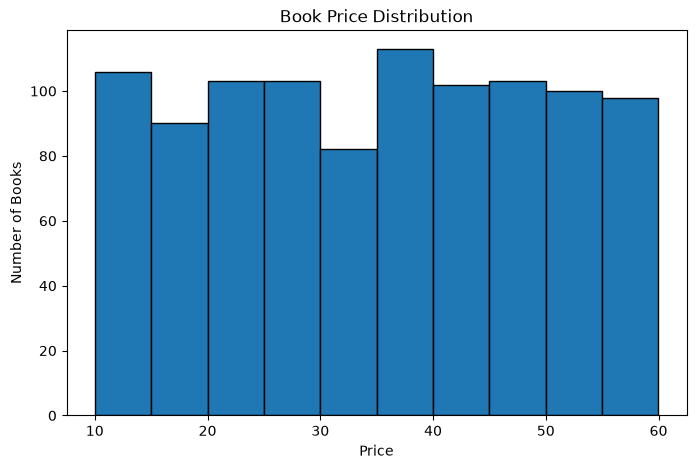

In [27]:
plt.figure(figsize=(8, 5))

plt.hist(df["Price"], bins=10, edgecolor="black")

plt.xlabel("Price")
plt.ylabel("Number of Books")
plt.title("Book Price Distribution")

plt.show()

## Books by Rating

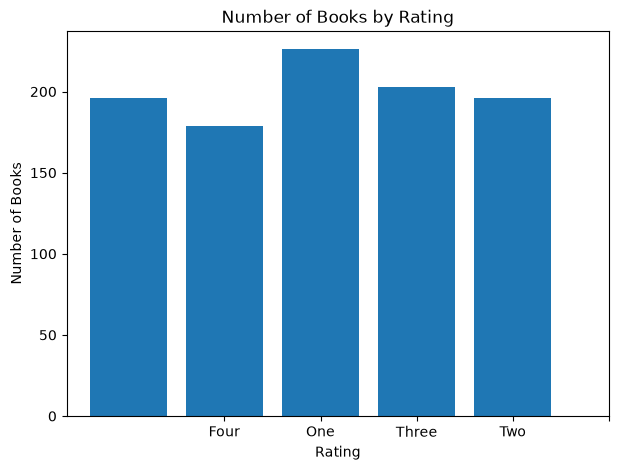

In [28]:
rating_counts = df["Rating"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(rating_counts.index, rating_counts.values)
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.title("Number of Books by Rating")
plt.xticks([1, 2, 3, 4, 5])
plt.show()